In [1]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

print("Libraries imported successfully. ✅")

Libraries imported successfully. ✅


Load test data

Why: We need the same dataset and feature structure used during training.

In [2]:
# Load feature-engineered data

df = pd.read_csv(
    "../data/processed/feature_engineered_data.csv"
)

print("Dataset loaded successfully. ✅")
print("Shape:", df.shape)

Dataset loaded successfully. ✅
Shape: (112, 18)


Define features and target

Why: Use exactly the same 14 features used during model training.

In [3]:
# Define features

feature_columns = [
    "founded_year",
    "sector",
    "subsector",
    "country",
    "city",
    "funding_usd_millions",
    "valuation_usd_millions",
    "employees",
    "startup_stage",
    "startup_age",
    "funding_log",
    "valuation_log",
    "funding_per_employee"
]

X = df[feature_columns].copy()

y = df["is_unicorn"].astype(int)

print("Features:", X.shape)
print("Target:", y.shape)

Features: (112, 13)
Target: (112,)


Create the same test split

Why: We need the same random_state and split used during training so evaluation uses the same unseen test records.

In [4]:
# Recreate the test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Test records:", len(X_test))

Test records: 23


Load the best model

Why: Load the trained model saved in 04_model_training.ipynb.

In [5]:
# Load the trained model

model = joblib.load(
    "../models/startup_success_model.pkl"
)

print("Model loaded successfully. ✅")

Model loaded successfully. ✅


Generate predictions

Why: Predict unicorn status for the unseen test data.

In [6]:
# Generate predictions

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully. ✅")

Predictions generated successfully. ✅


Calculate evaluation metrics

Why: Accuracy alone is not enough because our classes are imbalanced.

In [7]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))
print("ROC-AUC:", round(roc_auc, 3))

Accuracy: 0.913
Precision: 0.5
Recall: 1.0
F1 Score: 0.667
ROC-AUC: 0.952


Classification Report

Why: Gives precision, recall, and F1 separately for both classes.

In [8]:
# Display classification report

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        21
           1       0.50      1.00      0.67         2

    accuracy                           0.91        23
   macro avg       0.75      0.95      0.81        23
weighted avg       0.96      0.91      0.93        23



Confusion Matrix

Why: Shows correct and incorrect predictions for Unicorn and Non-Unicorn classes.

In [9]:
# Create confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[19  2]
 [ 0  2]]


Confusion Matrix Visualization

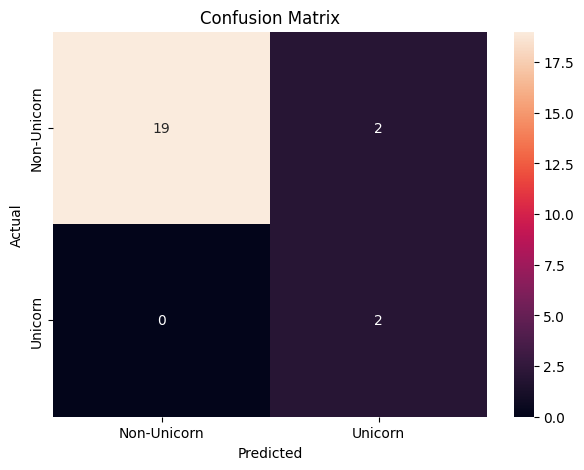

In [10]:
# Plot confusion matrix

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Non-Unicorn", "Unicorn"],
    yticklabels=["Non-Unicorn", "Unicorn"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

ROC Curve

Why: Shows how well the model separates Unicorn and Non-Unicorn startups across different thresholds.

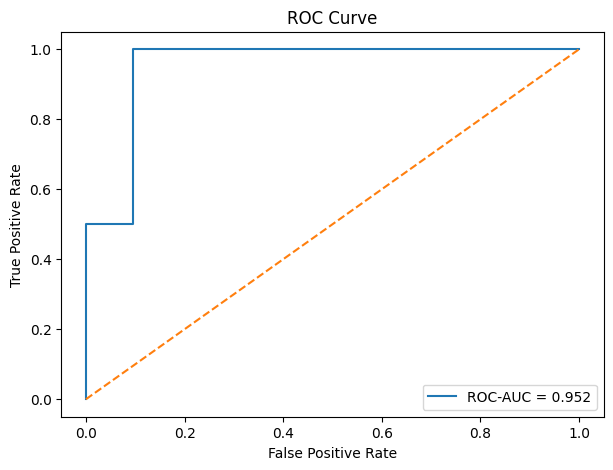

In [11]:
# Calculate ROC curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

Precision-Recall Curve

Why: With only 11 positive records, Precision-Recall is especially useful for evaluating the minority class.

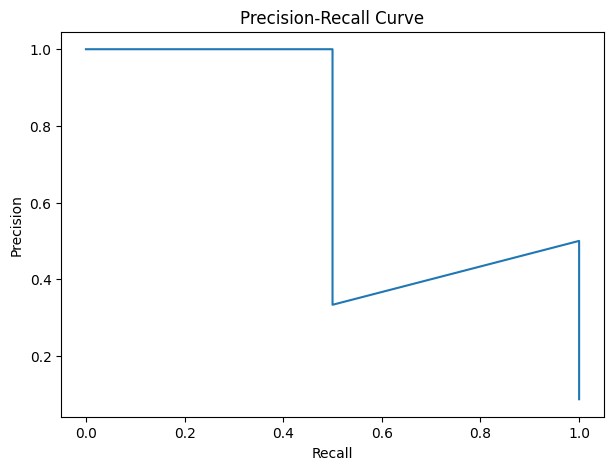

In [12]:
# Calculate precision-recall curve

precision_values, recall_values, _ = (
    precision_recall_curve(
        y_test,
        y_prob
    )
)

plt.figure(figsize=(7,5))

plt.plot(
    recall_values,
    precision_values
)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

Create evaluation summary

Why: Store the final model performance in a simple table.

In [13]:
# Create evaluation summary

evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(
    evaluation_df.round(3)
)

,Metric,Score
0,Accuracy,0.913
1,Precision,0.500
2,Recall,1.000
3,F1 Score,0.667
4,ROC-AUC,0.952


Save evaluation results

Why: Save the results for the final report and dashboard.

In [14]:
# Save evaluation results

evaluation_df.to_csv(
    "../reports/model_evaluation.csv",
    index=False
)

print("Evaluation results saved successfully. ✅")

Evaluation results saved successfully. ✅


Save confusion matrix

Why: Save the confusion matrix values for reporting.

In [15]:
# Save confusion matrix

confusion_df = pd.DataFrame(
    cm,
    index=["Actual Non-Unicorn", "Actual Unicorn"],
    columns=["Predicted Non-Unicorn", "Predicted Unicorn"]
)

confusion_df.to_csv(
    "../reports/confusion_matrix.csv"
)

print("Confusion matrix saved successfully. ✅")

Confusion matrix saved successfully. ✅


Final evaluation

Why: Final checkpoint before we move to the application

In [16]:
# Display final evaluation

print("========== FINAL MODEL EVALUATION ==========")

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))
print("ROC-AUC:", round(roc_auc, 3))

print("\nModel evaluation completed successfully. ✅")

========== FINAL MODEL EVALUATION ==========
Accuracy: 0.913
Precision: 0.5
Recall: 1.0
F1 Score: 0.667
ROC-AUC: 0.952

Model evaluation completed successfully. ✅
